In [17]:
import arviz as az
import numpy as np
from scipy.stats import wishart
import matplotlib.pyplot as plt
import math

# Set random seed for reproducibility (same seed of Mattia's 250D notebook)
rng = np.random.default_rng(12345)

Posterior to sample:

In [18]:
#def logprob_gaussian_10d(x):
#    logp = -0.5 * jnp.dot(x, x)
#    grad = -x
#    return logp, grad

# Define the pseudo log-potential
# Gaussian log-density
D = 10
df = D

# distribuzione fortemente anisotropica
#A = wishart.rvs(df=df, scale=np.eye(D), random_state=rng).astype(np.float64)

# Identita'
#A = np.eye(D, dtype=np.float64)

# Varianze diverse nelle variabili ma non correlate
sigmas = jnp.linspace(0.5, 5.0, D)  # varianze molto diverse
A = jnp.diag(1.0 / (sigmas**2))     # precisione = diag(1/σ²)

def L(theta: jnp.ndarray, precision_mat = A) -> jnp.float32:
    assert theta.ndim == 1
    return -0.5 * jnp.vdot(theta, precision_mat @ theta) 


#grad_L = jax.grad(L)
logprob_and_grad = jax.value_and_grad(L)

Initialization:

In [19]:
theta0 = jnp.zeros(10)
key = jrnd.PRNGKey(0)

Warmup configuration:

In [20]:
warmup_cfg = WarmupConfig(
    num_warmup=2000,
    delta=0.8,
    adapt_mass=False,   
)


Run the algorithm:

In [21]:
samples, epsilon_final = NUTS_sampler_wu(
    theta0=theta0,
    num_warmup=2000,
    num_samples=2000,
    key=key,
    warmup_cfg=warmup_cfg,
    j_max=10
)

Check:

In [22]:
len(samples)

2000

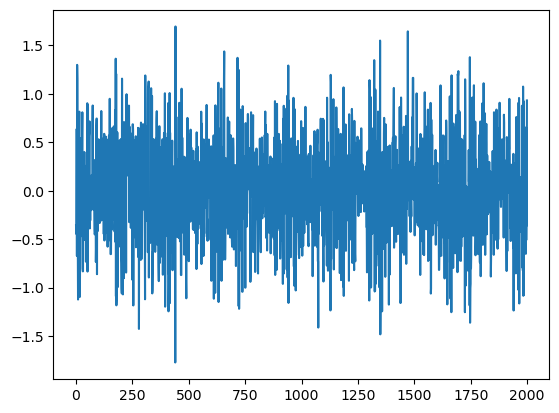

In [23]:
import matplotlib.pyplot as plt
plt.plot(samples[:,0])

In [24]:
print("Epsilon after the warmup:", epsilon_final)

Epsilon after the warmup: 0.7335638


In [25]:
print("mean:", samples.mean(axis=0))

mean: [-0.00265101 -0.0029813   0.00749373  0.05748774 -0.07961354  0.02557101
 -0.16376911 -0.3758351  -0.315542   -0.38676023]


In [26]:
print("std:", samples.std(axis=0))

std: [0.5049156 0.9705424 1.4966661 2.0610194 2.606206  3.1136608 3.4994135
 4.2706065 5.0856576 5.226028 ]


In [27]:
samples.shape

(2000, 10)

/home/pira/miniconda3/envs/inf/lib/python3.11/site-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


array([[<Axes: ylabel='theta\n0'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n1'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n2'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n3'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n4'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n5'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n6'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='theta\n0', ylabel='theta\n7'>,
        <Axes: xlabel='theta\n1'>, <Axes: xlabel='theta\n2'>,
        <Axes: xlabel='theta\n3'>, <Axes: xlabel='theta\n4'>,
        <Axes: xlabel='t

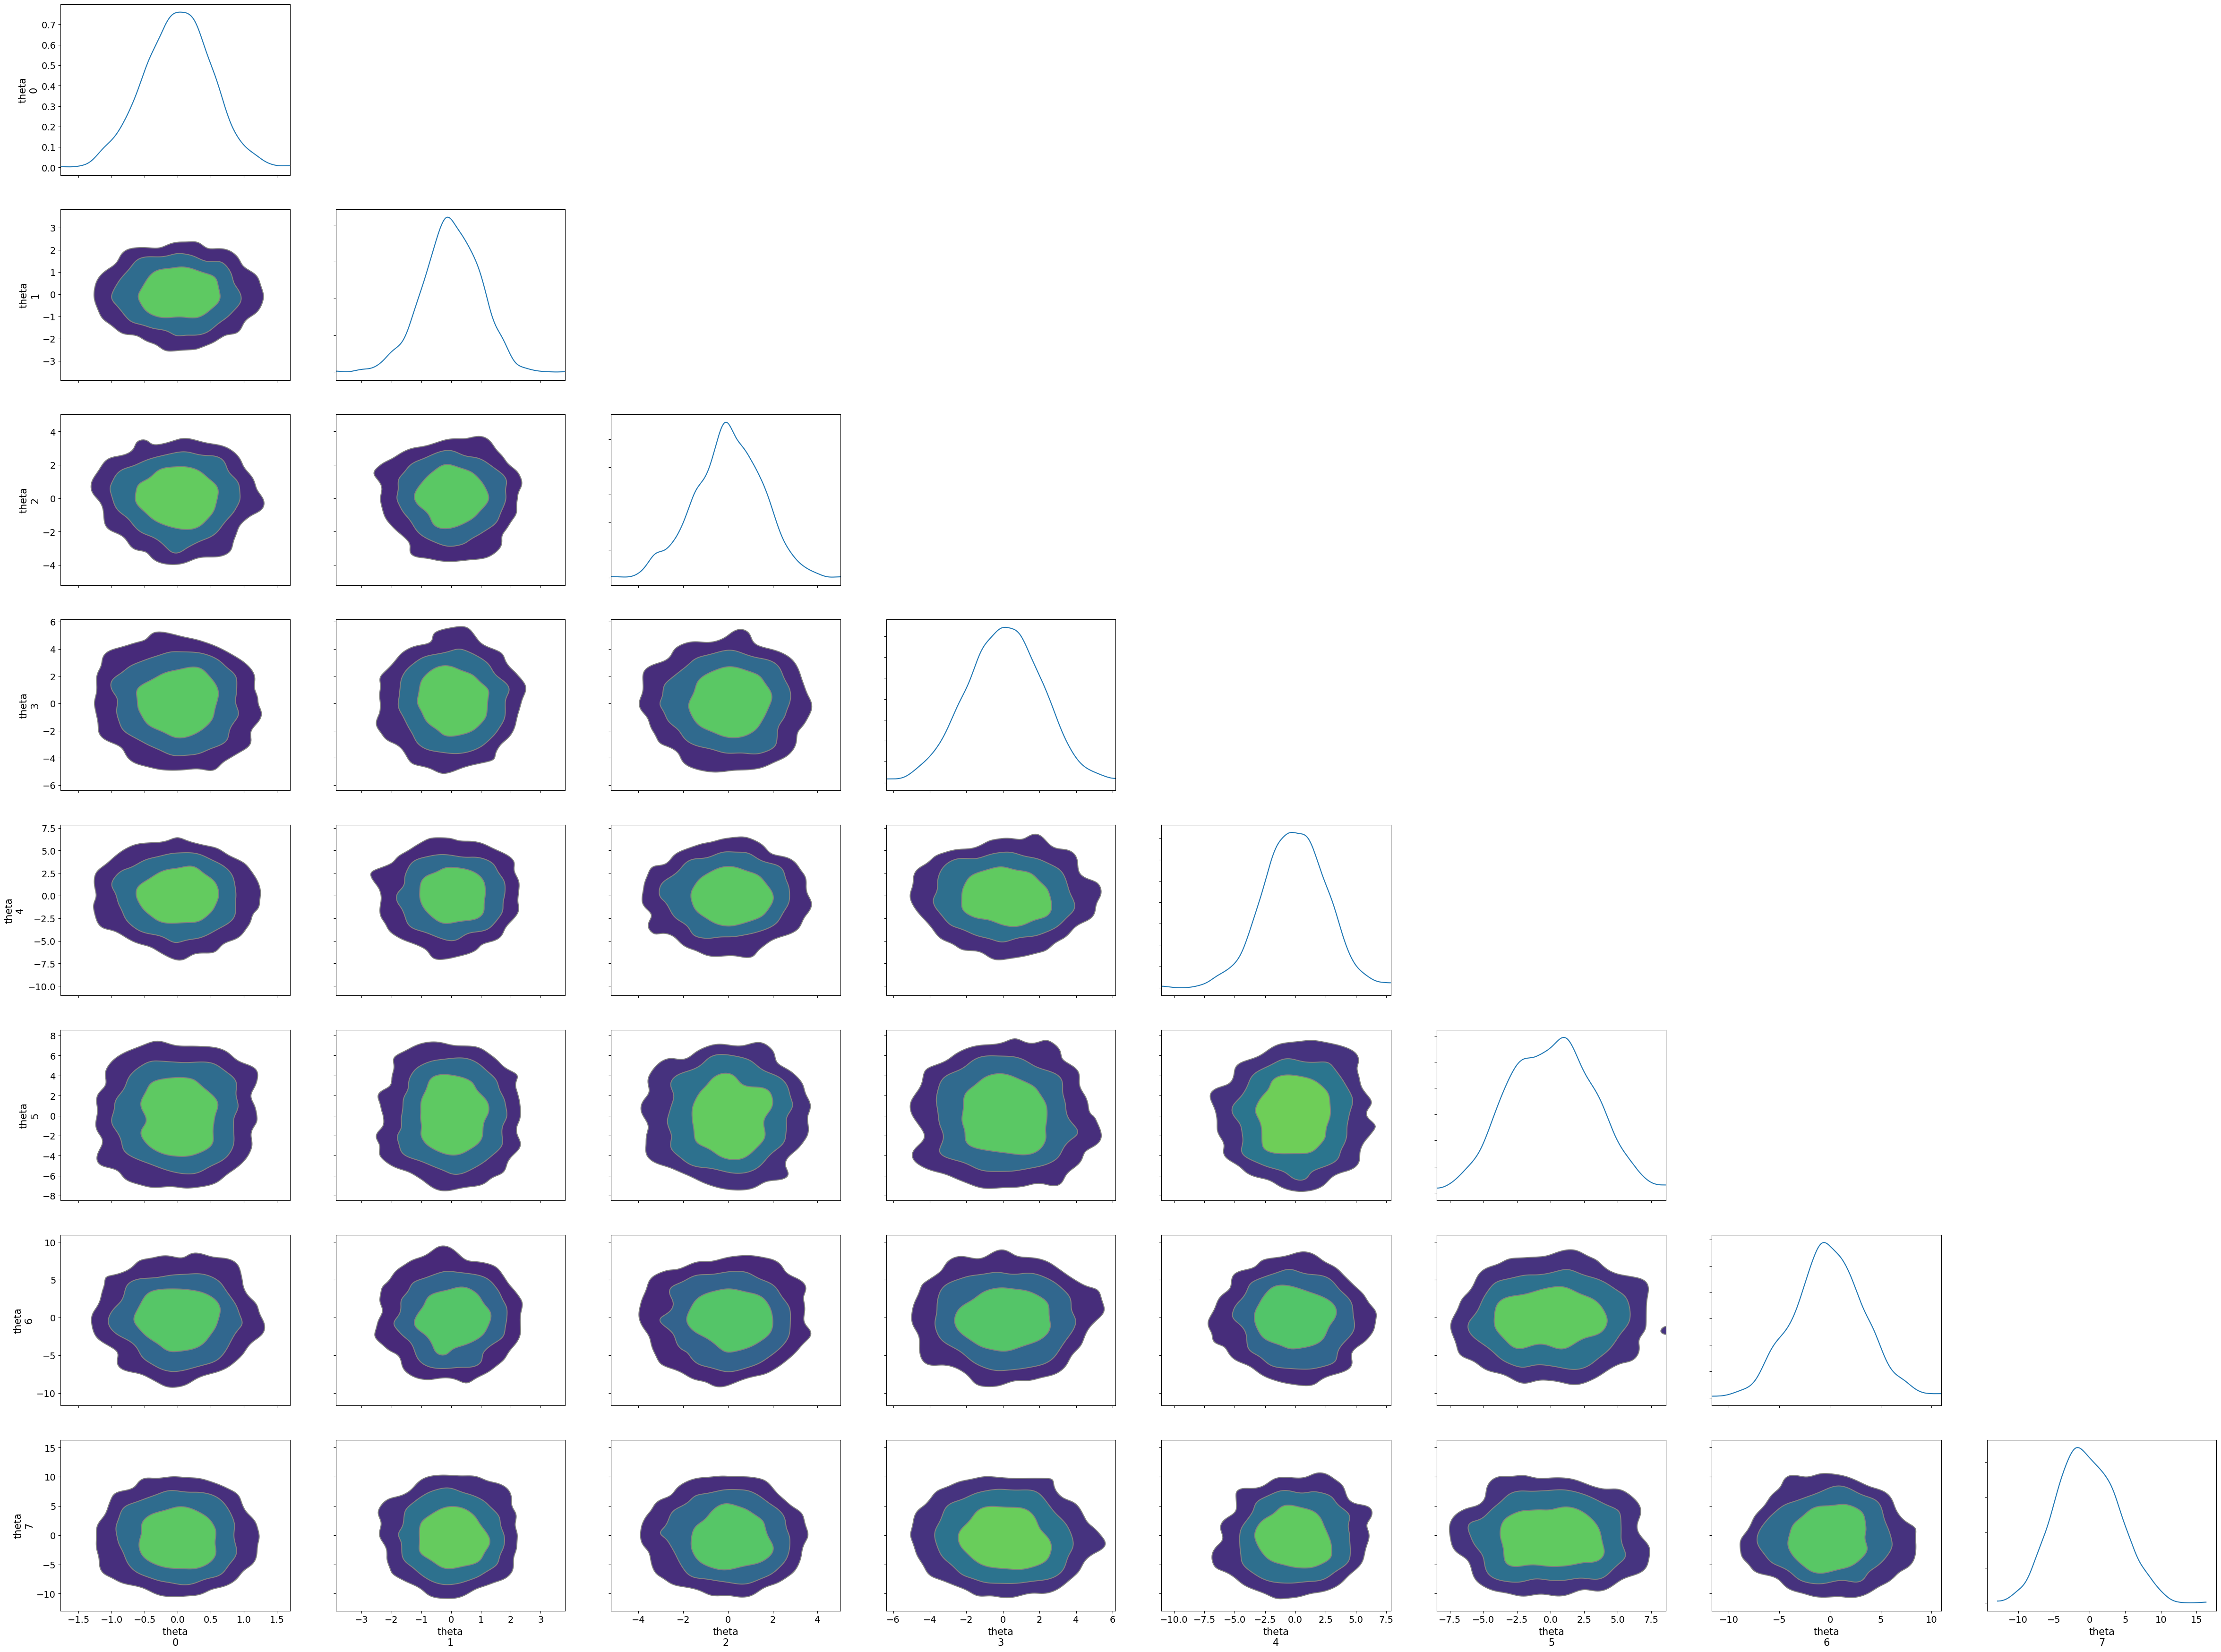

In [28]:
# add a pseudo dimension to plot the data
samples = samples[None, :, :]   # shape diventa (1, 1000, 10)

# plot the sampled data marginalized distributions
idata = az.from_dict(
    posterior={"theta": samples},
    coords={"theta_dim": np.arange(samples.shape[-1])},
    dims={"theta": ["chain", "draw", "theta_dim"]},
)

az.plot_pair(idata, var_names=["theta"], kind="kde", marginals=True)

In [29]:
# The theorical variance of each variable comes from inverting the precision matrix A
th_cov_mat = np.linalg.inv(A)
th_var_k = [ th_cov_mat[i,i] for i in range(D) ]
th_var_k

[np.float32(0.25),
 np.float32(1.0),
 np.float32(2.25),
 np.float32(4.0),
 np.float32(6.25),
 np.float32(9.0),
 np.float32(12.250001),
 np.float32(16.0),
 np.float32(20.25),
 np.float32(25.0)]

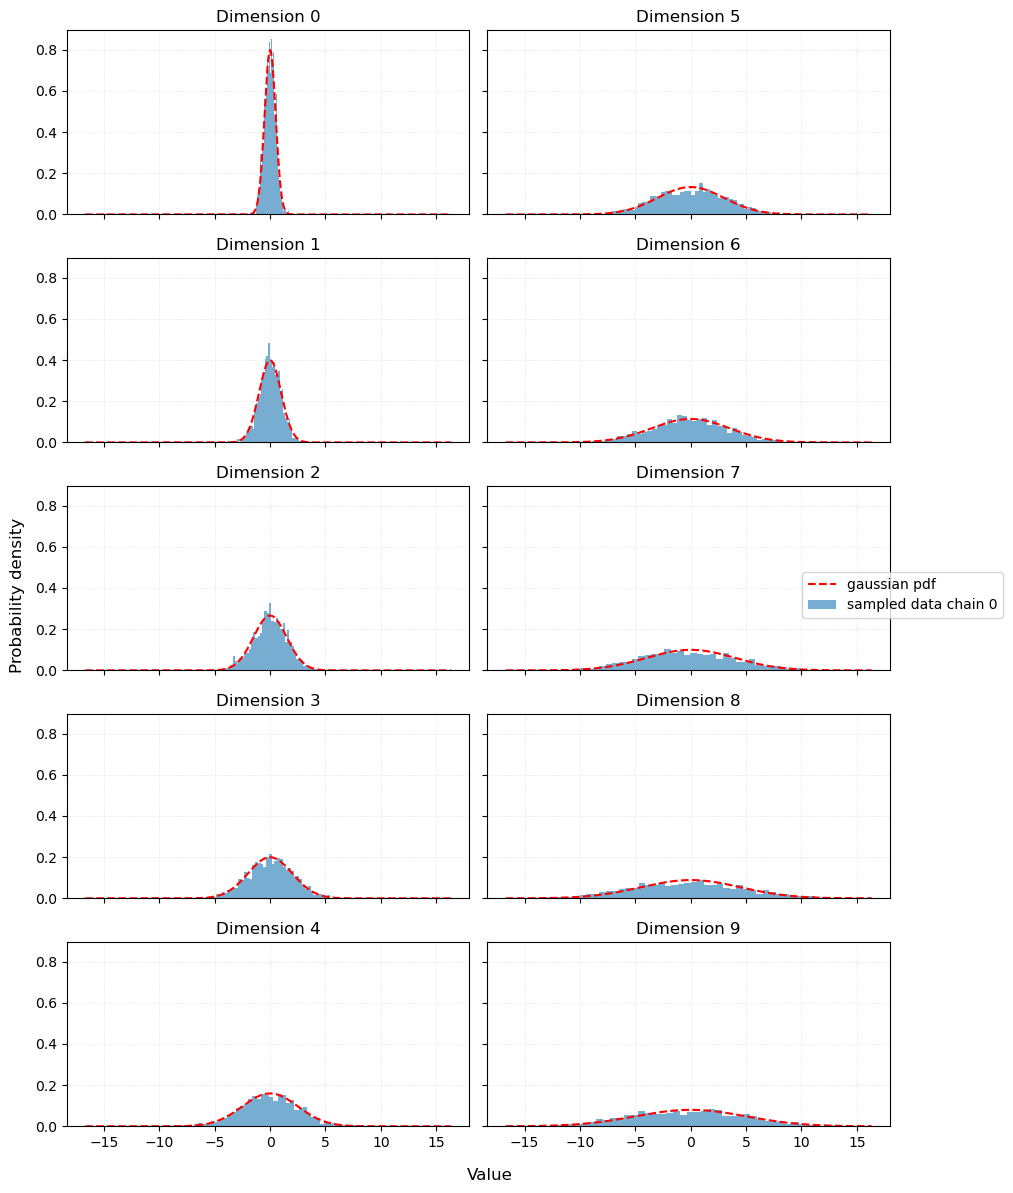

In [30]:
x = np.linspace(samples.min(), samples.max(), 1000)

fig, axs = plt.subplots(5, 2, figsize=(10, 12), sharex=True, sharey=True)

for j in range(2):        # columns
    for i in range(5):    # rows
        
        k = i + 5*j       # global index of the variable (0..9)

        var = th_var_k[k]
        norm_factor = 1 / np.sqrt(2 * np.pi * var)
        pdf = norm_factor * np.exp(-(x**2) / (2 * var))

        axs[i, j].plot(x, pdf, color='red', label='gaussian pdf', linestyle= '--')
        axs[i, j].hist(samples[0,:, k] , bins=50, density=True, alpha=0.6, label='sampled data chain 0')
        #axs[i, j].hist(samples_flat[2000:4000, k] , bins=50, density=True, alpha=0.6, label='sampled data chain 1')

        # add a grid
        axs[i, j].grid(True, linestyle=':', linewidth=0.5, alpha=0.5)

        axs[i, j].set_title(f"Dimension {k}")

# --- LEGENDA UNICA ---
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.02, 0.5))

# --- ETICHETTE GLOBALI ---
fig.supxlabel("Value")
fig.supylabel("Probability density")

plt.tight_layout()
plt.subplots_adjust(right=0.9)
plt.show()

## Kolmogorov-Smirnov test
https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kstest.html

The Kolmogorov-Smirnov test is suitable only for 1D distributions, so let's use it to evaluate the distributions of the sampled data along the single directions. In this way we can evaluate how much every single variable empirical distribution is far/near the theoretical one. Here I performed only the KS-test to verify if the distribution of a single chain comes from the theoretical gaussian distribuiton adopted to generate them via NUTS. We can also use the KS-test to check if two chains come from the same distribution...
Start looking at the single variable data sampled with NUTS:

In [31]:
# For now work only on the first chain, then generalize for n chains...
from scipy.stats import kstest, norm

# y = 1D samples (j-th component)
stats = []
pvals = []

for j in range(D-1):
    comp = np.asarray(samples[:, j])   # conversione esplicita
    stat, pval = kstest(comp[:,j], 'norm', args=(0, 1))
    stats.append(float(stat))
    pvals.append(float(pval))
    

print("KS statistic: \n", stats, "\n")
print("p-value: \n", pvals, "\n")




KS statistic: 
 [0.6396839040465335, 0.7203206016642307, 0.5521605806109631, 0.8439062519897982, 0.6008122370083812, 0.9954231820782571, 0.9999995609262357, 0.9998715796586141, 0.999993484357362] 

p-value: 
 [0.720632191906933, 0.5593587966715385, 0.8956788387780739, 0.31218749602040363, 0.7983755259832377, 0.00915363584348583, 8.781475286934182e-07, 0.000256840682771875, 1.3031285275966198e-05] 



In the test we have:

$$
H_0 : \text{the sample follows the theoretical distribution} \ F(x) \\
H_1 : \text{the sample comes from another distribution} 
$$

The $p-value$ tells us how confident we are in accepting $H_0$. Hence, with a such small values we reject the $H_0$ hypotesis.

This is what we expect if we don't perform a whightening procedure on the data. The Whitening is a procedure to transport our data in another space where they follow a gaussian distribution with mean 0. So, let's do the same but with the whitening procedure.

In [32]:

Sigma = np.linalg.inv(A)   # A è già NumPy

stats = []
pvals = []

for j in range(D):
    comp = np.asarray(samples[0, :, j])   # JAX → NumPy
    std = np.sqrt(Sigma[j, j])         # deviazione standard teorica
    stat, pval = kstest(comp, 'norm', args=(0, std))
    stats.append(stat)
    pvals.append(pval)


print("KS statistic: \n", stats, "\n")
print("p-value: \n", pvals, "\n")

KS statistic: 
 [np.float64(0.015888190677095793), np.float64(0.022781124168944122), np.float64(0.027713569329936516), np.float64(0.03319698680362504), np.float64(0.026891279856554873), np.float64(0.03322175279787681), np.float64(0.027477626997943205), np.float64(0.06944060404915053), np.float64(0.0692341423067061), np.float64(0.057873095500717064)] 

p-value: 
 [np.float64(0.6874377352328259), np.float64(0.2466334970894194), np.float64(0.09091992455998898), np.float64(0.023807838444855567), np.float64(0.10886451798218222), np.float64(0.023651254198708664), np.float64(0.09579593879346038), np.float64(7.873386106775333e-09), np.float64(8.83201748930969e-09), np.float64(2.8989774800232495e-06)] 



In [33]:
print(Sigma)

[[ 0.25      0.        0.        0.        0.        0.        0.
   0.        0.        0.      ]
 [ 0.        1.        0.        0.        0.        0.        0.
   0.        0.        0.      ]
 [ 0.        0.        2.25      0.        0.        0.        0.
   0.        0.        0.      ]
 [ 0.        0.        0.        4.        0.        0.        0.
   0.        0.        0.      ]
 [ 0.        0.        0.        0.        6.25      0.        0.
   0.        0.        0.      ]
 [ 0.        0.        0.        0.        0.        9.        0.
   0.        0.        0.      ]
 [ 0.        0.        0.        0.        0.        0.       12.250001
   0.        0.        0.      ]
 [ 0.        0.        0.        0.        0.        0.        0.
  16.        0.        0.      ]
 [ 0.        0.        0.        0.        0.        0.        0.
   0.       20.25      0.      ]
 [ 0.        0.        0.        0.        0.        0.        0.
   0.        0.       25.      ]]


In [34]:
emp_cov = np.cov(samples[0], rowvar=False)
print(emp_cov)

[[ 2.55067259e-01 -1.01175760e-02 -1.40507097e-02 -3.64778690e-02
  -1.93049851e-02  1.21291675e-02  1.13412882e-02 -8.47912775e-03
  -9.82175026e-02  2.17431794e-03]
 [-1.01175760e-02  9.42423558e-01 -4.75802968e-02  3.26746611e-02
   2.15904123e-02 -3.94692201e-02  4.76289111e-02 -5.02351235e-03
  -2.37082912e-01 -2.45332077e-01]
 [-1.40507097e-02 -4.75802968e-02  2.24113009e+00 -4.46212645e-02
   1.04167269e-01 -4.78545667e-02  6.93970130e-03 -1.33778142e-01
  -1.05638125e-01 -7.55125885e-03]
 [-3.64778690e-02  3.26746611e-02 -4.46212645e-02  4.24992635e+00
  -1.94799350e-01 -9.10205492e-02 -8.23852776e-02 -4.74688294e-01
   6.34204676e-01 -3.81679913e-01]
 [-1.93049851e-02  2.15904123e-02  1.04167269e-01 -1.94799350e-01
   6.79570643e+00  2.60121490e-01 -3.22259480e-01  5.90990847e-01
   5.25856649e-01 -5.86216642e-01]
 [ 1.21291675e-02 -3.94692201e-02 -4.78545667e-02 -9.10205492e-02
   2.60121490e-01  9.69973515e+00  2.82726627e-01 -1.05544177e-01
   3.31941136e-01  6.26769604e-01

In [35]:
rel_err = np.abs(emp_cov - Sigma) / np.abs(Sigma)
print(rel_err)

[[2.02690364e-02            inf            inf            inf
             inf            inf            inf            inf
             inf            inf]
 [           inf 5.75764421e-02            inf            inf
             inf            inf            inf            inf
             inf            inf]
 [           inf            inf 3.94218230e-03            inf
             inf            inf            inf            inf
             inf            inf]
 [           inf            inf            inf 6.24815879e-02
             inf            inf            inf            inf
             inf            inf]
 [           inf            inf            inf            inf
  8.73130281e-02            inf            inf            inf
             inf            inf]
 [           inf            inf            inf            inf
             inf 7.77483502e-02            inf            inf
             inf            inf]
 [           inf            inf            inf            

/tmp/ipykernel_16798/3810979290.py:1: RuntimeWarning: divide by zero encountered in divide
  rel_err = np.abs(emp_cov - Sigma) / np.abs(Sigma)


In [36]:
def qq_plot_marginals(samples, Sigma):
    """
    samples: array (N, D)
    Sigma: covarianza teorica (D, D) = A^{-1}
    """
    samples = np.asarray(samples)
    Sigma = np.asarray(Sigma)

    N, D = samples.shape
    rows, cols = 5, 2  # per D=10

    fig, axes = plt.subplots(rows, cols, figsize=(12, 20))
    axes = axes.flatten()

    for j in range(D):
        ax = axes[j]

        # campioni della dimensione j
        x = np.sort(samples[:, j])

        # quantili teorici della normale con varianza Sigma[j,j]
        std = np.sqrt(Sigma[j, j])
        q = norm.ppf(np.linspace(0.001, 0.999, N), loc=0.0, scale=std)

        # QQ plot
        ax.plot(q, x, 'o', markersize=2)
        ax.plot(q, q, 'r--', linewidth=1)

        ax.set_title(f"Dim {j} — std teorica={std:.3f}")
        ax.set_xlabel("Quantili teorici")
        ax.set_ylabel("Quantili empirici")
        ax.grid(True)

    # rimuovi subplot vuoti se D < rows*cols
    for k in range(D, rows*cols):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.show()



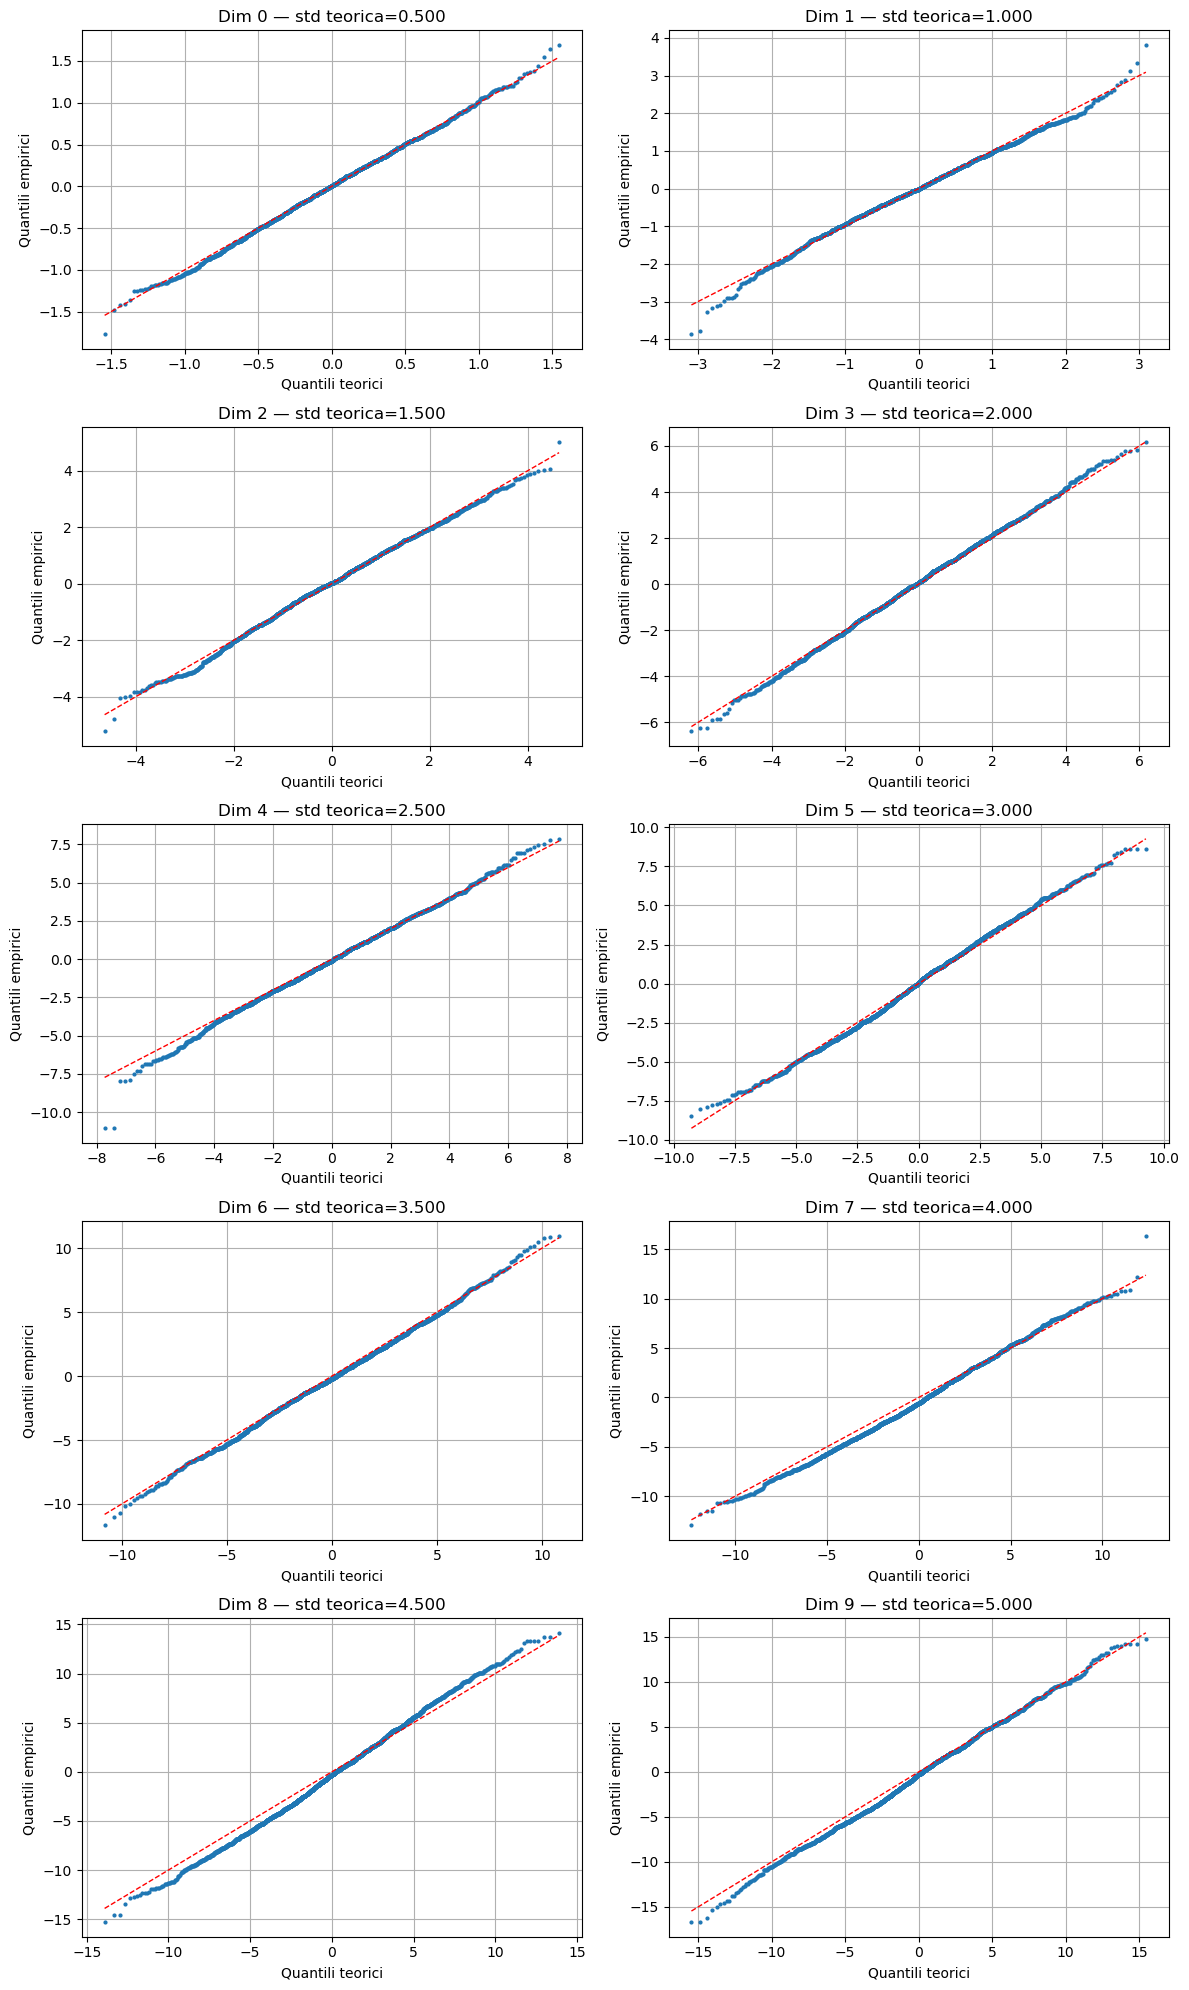

In [37]:
qq_plot_marginals(samples[0], Sigma)